# AOC 期末專題 ── 第 2 組
# RMSNorm ＋ INT8 量化 ＋ **Scale Tying（尺度共享）**：ViT-Small/16 on ImageNet-1k

> **實驗目的**：在 RMSNorm + INT8 量化基礎上加入 **Scale Tying**，
> 比較三種 PTQ 策略（Per-Channel / Per-Tensor / Per-Block）與兩種 QAT 策略，
> 確認模型是否崩潰、精度損失是否在規格書容許範圍。

---

## Scale Tying 是什麼？

量化公式：`W_int = clamp(round(W_fp32 / scale), -127, 127)`
推論還原：`W_fp32 ≈ W_int × scale`

**關鍵問題**：`scale` 的粒度多細？

| 策略 | Scale 粒度 | 全模型 Scale 數 | 量化誤差 | FPGA 硬體成本 |
|------|-----------|---------------|---------|-------------|
| **Per-Channel**（基準） | 每個 output channel 一個 | ~28,000 個 | 最低 | 最高（BRAM 向量查表） |
| **Per-Tensor**（層級共享） | 整層共用 1 個 scalar | ~98 個 | 中 | 中（每層 1 暫存器） |
| **Per-Block**（Block 級，推薦） | 同 Block 8 Linear 共用 1 個 | **12 個** | 較高 | **最低**（12 暫存器，零 BRAM） |

### 為何 Per-Block 最適合 PYNQ-Z2（Zynq XC7Z020）？
- ViT-Small：12 個 Transformer Block × 8 Linear/Block = 96 個 Linear
- Per-Block：全模型只需 **12 個** scale 值 → 全放進 LUT 暫存器，**不佔 BRAM**
- Dequant 硬體：每個 Block 只需一個固定乘法器（DSP slice），不需 BRAM 查表
- 與 §6.6 PPU 串流設計兼容：scale 隨 Block token 一起 pipeline

## 實驗流程

```
ViT-Small（RMSNorm 7ep 分段訓練已完成）→ 載入 Stage B checkpoint
   │
   ├─ PTQ Per-Channel  ──────────────────→ acc_ptq_perchan（基準，最精確）
   ├─ PTQ Per-Tensor   ──────────────────→ acc_ptq_pertens（層級共享）
   ├─ PTQ Per-Block    ──────────────────→ acc_ptq_perblk （Block 共享）
   │
   ├─ QAT Per-Channel  3ep ─────────────→ acc_qat_perchan（基準）
   └─ QAT Per-Block    3ep ─────────────→ acc_qat_perblk （Scale Tying + STE）
```

## 崩潰判定（規格書 v3.1）
- **RMSNorm ΔAcc ≥ −0.2 pp**（§6.6）
- **INT8 ΔAcc ≥ −0.3 pp**（Phase 1）
- Per-Block QAT 若達標 → 可採用零 BRAM 的最省方案部署 PYNQ-Z2


In [1]:
# ═══════════════════════════════════════════════════════════════
# Step 1A：安裝依賴套件
# ═══════════════════════════════════════════════════════════════
import subprocess, sys
for pkg in ["timm>=1.0", "tqdm"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
print("依賴安裝完成")


依賴安裝完成


✅ 繁體中文字型：Microsoft JhengHei


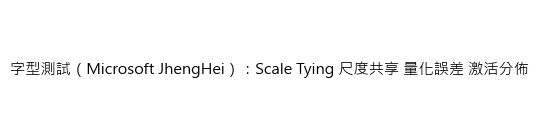

In [2]:
# ═══════════════════════════════════════════════════════════════
# Step 1B：繁體中文字型設定（Microsoft JhengHei 優先）
# ═══════════════════════════════════════════════════════════════
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches

ZH_CANDIDATES = ["Microsoft JhengHei", "Noto Sans TC", "Noto Serif TC",
                  "DFKai-SB", "MingLiU"]
available = {f.name for f in fm.fontManager.ttflist}
ZH_FONT   = next((f for f in ZH_CANDIDATES if f in available), None)

if ZH_FONT:
    matplotlib.rcParams['font.family']        = ZH_FONT
    matplotlib.rcParams['axes.unicode_minus'] = False
    print(f"✅ 繁體中文字型：{ZH_FONT}")
else:
    print("⚠  未找到繁體中文字型，圖表中文可能顯示方框")

fig, ax = plt.subplots(figsize=(6, 1.5))
ax.text(0.5, 0.5,
        f"字型測試（{ZH_FONT}）：Scale Tying 尺度共享 量化誤差 激活分佈",
        ha='center', va='center', fontsize=11)
ax.axis('off')
plt.tight_layout(); plt.show()


In [3]:
# ═══════════════════════════════════════════════════════════════
# Step 1C：匯入所有函式庫
# ═══════════════════════════════════════════════════════════════
import os, time, copy, math, warnings, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import timm
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from collections import OrderedDict

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA 可用 : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")


PyTorch  : 2.9.1+cu128
timm     : 1.0.26
CUDA 可用 : True
GPU      : NVIDIA GeForce RTX 5060


In [4]:
# ═══════════════════════════════════════════════════════════════
# Step 1D：全域設定（所有超參數集中管理）
# ═══════════════════════════════════════════════════════════════

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 路徑 ──────────────────────────────────────────────────────
IMAGENET_VAL_DIR = r"C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\第二階段\IMAGENET_VAL_HF"
# 重用 Phase0+1 已訓練好的 RMSNorm checkpoint（Stage B 最佳模型）
PREV_CKPT_DIR    = "./ckpt_rms_quant"
# Scale Tying 新實驗結果存這裡，不蓋掉 Phase0+1 的結果
CKPT_DIR         = "./ckpt_scale_tying"
os.makedirs(CKPT_DIR,      exist_ok=True)
os.makedirs(PREV_CKPT_DIR, exist_ok=True)

# ── 影像設定 ──────────────────────────────────────────────────
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── 批次設定 ──────────────────────────────────────────────────
BATCH_TRAIN = 64
BATCH_EVAL  = 128

# ── 量化設定 ──────────────────────────────────────────────────
QUANT_BITS = 8
QUANT_MAX  = 2 ** (QUANT_BITS - 1) - 1   # 127（對稱 INT8）

# ── RMSNorm 分段訓練超參數（與 Phase0+1 相同，複用 checkpoint）──
STAGE_A_EPOCHS      = 2
STAGE_A_BASE_LR     = 3e-4
STAGE_A_UNFREEZE    = 6
STAGE_B_EPOCHS      = 5
STAGE_B_BASE_LR     = 1e-4
STAGE_B_LAYER_DECAY = 0.75

# ── QAT 超參數 ────────────────────────────────────────────────
QAT_EPOCHS = 3      # PTQ 已收斂，QAT 只需少量 epoch 適應量化誤差
QAT_LR     = 2e-5   # 遠低於 FP32 微調，避免破壞已收斂的 RMS 權重

# ── 規格書標準（v3.1）────────────────────────────────────────
SPEC_RMS_THRESHOLD  = -0.2   # §6.6 RMSNorm：ΔAcc ≥ -0.2pp
SPEC_INT8_THRESHOLD = -0.3   # Phase 1 INT8：ΔAcc ≥ -0.3pp

print(f"裝置         : {DEVICE}")
print(f"ImageNet     : {IMAGENET_VAL_DIR}")
print(f"  存在       : {os.path.isdir(IMAGENET_VAL_DIR)}")
rms_b = PREV_CKPT_DIR + '/rms_stage_b.pt'
print(f"RMS-FP32 ckpt: {rms_b}")
print(f"  存在       : {os.path.exists(rms_b)}")
print(f"Scale Tying  : {CKPT_DIR}")


裝置         : cuda
ImageNet     : C:\Users\User\Desktop\AOC_Final\炸彈惡魔\提報後重新規劃\IMAGENET_VAL_HF
  存在       : True
RMS-FP32 ckpt: ./ckpt_rms_quant/rms_stage_b.pt
  存在       : True
Scale Tying  : ./ckpt_scale_tying


---
## Step 2：ImageNet 資料集載入

In [5]:
# ═══════════════════════════════════════════════════════════════
# Step 2：IMAGENET_VAL_HF 載入 + Stratified 80/20 分割
# ═══════════════════════════════════════════════════════════════
assert os.path.isdir(IMAGENET_VAL_DIR), f"路徑不存在：{IMAGENET_VAL_DIR}"

transform_eval = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
transform_train = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

inet_eval  = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_eval)
inet_train = datasets.ImageFolder(IMAGENET_VAL_DIR, transform=transform_train)

cls_to_idx = {}
for idx, (_, label) in enumerate(inet_eval.samples):
    cls_to_idx.setdefault(label, []).append(idx)

rng = random.Random(SEED)
train_idx, test_idx, calib_idx = [], [], []
for label, indices in cls_to_idx.items():
    s = indices[:]; rng.shuffle(s)
    n_tr = int(len(s) * 0.8)
    train_idx.extend(s[:n_tr])
    test_idx.extend(s[n_tr:])
    calib_idx.extend(s[:1])   # 每類 1 張 → 共 1000 張校準集

train_loader = DataLoader(Subset(inet_train, train_idx),
                          batch_size=BATCH_TRAIN, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(Subset(inet_eval,  test_idx),
                          batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)
calib_loader = DataLoader(Subset(inet_eval,  calib_idx),
                          batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)
full_loader  = DataLoader(inet_eval,
                          batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)

print(f"資料集  : {len(inet_eval):,} 張 / {len(inet_eval.classes)} 類")
print(f"訓練集  : {len(train_idx):,} 張  測試集 : {len(test_idx):,} 張  校準集 : {len(calib_idx)} 張")
print(f"訓練 batch : {len(train_loader)}  測試 batch : {len(test_loader)}")


資料集  : 46,429 張 / 1000 類
訓練集  : 36,720 張  測試集 : 9,709 張  校準集 : 1000 張
訓練 batch : 574  測試 batch : 76


---
## Step 3：所有模組定義（RMSNorm ＋ PTQ ＋ QAT ＋ Scale Tying）

本步驟定義 5 個核心模組：
1. **RMSNorm**：替換 LayerNorm，FPGA 友好（1次遍歷，無 β）
2. **PTQ Per-Channel**：基準量化（每 output row 一個 scale）
3. **PTQ Scale Tying**：Per-Tensor 與 Per-Block 兩種粒度
4. **QAT Per-Channel STE**：基準 QAT（梯度穿透 round）
5. **QAT Per-Block Scale Tying**：`ScaleTieGroup` + `QuantLinearBlockTied` + 預掛鉤

In [6]:
# ═══════════════════════════════════════════════════════════════
# Step 3A：RMSNorm 模組
# ═══════════════════════════════════════════════════════════════
#
# 公式：y = (x / RMS(x)) * γ，  RMS(x) = sqrt(mean(x²))
# vs LayerNorm：需算 μ 再算 σ²（2 次遍歷），RMSNorm 只需 1 次
# 無 β 偏移：省去 384×25=9600 個 FP32 參數的 BRAM 儲存

class RMSNorm(nn.Module):
    '''
    Root Mean Square Layer Normalization (Zhang & Sennrich, 2019)
    接口與 nn.LayerNorm 相容（drop-in replacement）
    '''
    def __init__(self, normalized_shape, eps=1e-6, elementwise_affine=True):
        super().__init__()
        self.normalized_shape  = (normalized_shape,) if isinstance(normalized_shape, int)                                   else tuple(normalized_shape)
        self.eps               = eps
        self.elementwise_affine = elementwise_affine
        self.weight = nn.Parameter(torch.ones(self.normalized_shape))                       if elementwise_affine else None
        self.bias   = None   # RMSNorm 無 β，顯式宣告 None

    def forward(self, x):
        orig = x.dtype
        xf   = x.float()
        # rsqrt = 1/sqrt：一次運算完成（FPGA 對應 lut_inv_sqrt）
        inv  = torch.rsqrt(xf.pow(2).mean(-1, keepdim=True) + self.eps)
        out  = xf * inv
        if self.weight is not None:
            out = out * self.weight.float()
        return out.to(orig)

    def extra_repr(self):
        return f"shape={self.normalized_shape}, eps={self.eps}"


print("RMSNorm 定義完成")


RMSNorm 定義完成


In [7]:
# ═══════════════════════════════════════════════════════════════
# Step 3B：QAT Per-Channel STE（基準 QAT）
# ═══════════════════════════════════════════════════════════════
#
# STE = Straight-Through Estimator
# 前向：W_fq = round(W / scale) * scale  → 模擬 INT8 量化誤差
# 反向：∂round/∂W = 1（直接穿透）
#
# Per-Channel：scale[i] = max(|W[i,:]|) / 127（向量，每 output row 一個）

class STEQuantFunc(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, max_int):
        return torch.clamp(torch.round(x / scale), -max_int, max_int) * scale

    @staticmethod
    def backward(ctx, grad):
        return grad, None, None   # STE：梯度直接穿透 round


class QuantLinearSTE(nn.Linear):
    '''
    Per-Channel QAT Linear（基準）
    scale 形狀：[out_features, 1]（每 output channel 一個 scale）
    '''
    def forward(self, x):
        # per-channel scale（每次 forward 從當前 weight 重算，detach 阻梯度）
        scale = (self.weight.abs().max(dim=1, keepdim=True)[0] / QUANT_MAX
                 ).detach().clamp(1e-9)
        if self.training:
            w_fq = STEQuantFunc.apply(self.weight, scale, QUANT_MAX)
        else:
            w_fq = torch.clamp(torch.round(self.weight / scale),
                               -QUANT_MAX, QUANT_MAX) * scale
        return F.linear(x, w_fq, self.bias)


def inject_ste_perchannel(model_fp32, skip_head=True):
    '''替換所有 Linear（除 head）為 QuantLinearSTE（per-channel）'''
    model_q  = copy.deepcopy(model_fp32)
    head_mod = getattr(model_q, "head", None)
    n = 0
    for parent in list(model_q.modules()):
        for name, child in list(parent.named_children()):
            if not isinstance(child, nn.Linear): continue
            if skip_head and child is head_mod:  continue
            new = QuantLinearSTE(child.in_features, child.out_features,
                                 child.bias is not None)
            new.weight.data.copy_(child.weight.data)
            if child.bias is not None: new.bias.data.copy_(child.bias.data)
            setattr(parent, name, new)
            n += 1
    print(f"[inject-STE per-channel] 替換 {n} 個 Linear（head 保留 FP32）")
    return model_q


print("QAT Per-Channel STE 定義完成")


QAT Per-Channel STE 定義完成


In [8]:
# ═══════════════════════════════════════════════════════════════
# Step 3C：PTQ Scale Tying 三種策略
# ═══════════════════════════════════════════════════════════════
#
# ┌─────────────────────────────────────────────────────────────┐
# │  策略         │ scale 粒度   │ 全模型 scale 數 │ 量化誤差  │
# ├─────────────────────────────────────────────────────────────┤
# │ Per-Channel   │ 每 output row│ ~28,000        │ 最低      │
# │ Per-Tensor    │ 整層 1 個   │ ~98            │ 中        │
# │ Per-Block     │ 整 Block 1  │ 12             │ 較高      │
# └─────────────────────────────────────────────────────────────┘

def quantize_ptq_perchannel(model_fp32):
    """Per-Channel PTQ：每個 output channel 獨立 scale（基準，最精確）"""
    model_q = copy.deepcopy(model_fp32).cpu().eval()
    n_layers = 0
    with torch.no_grad():
        for m in model_q.modules():
            if not isinstance(m, nn.Linear): continue
            W     = m.weight.data
            scale = W.abs().max(dim=1, keepdim=True)[0].clamp(1e-9) / QUANT_MAX  # [out,1]
            m.weight.data = torch.clamp(torch.round(W / scale), -QUANT_MAX, QUANT_MAX) * scale
            n_layers += 1
    n_out  = sum(m.out_features for m in model_fp32.modules() if isinstance(m, nn.Linear))
    print(f"[PTQ Per-Channel]  {n_layers} 層量化，scale 向量總計 {n_out} 個")
    return model_q


def quantize_ptq_pertensor(model_fp32):
    """
    Per-Tensor PTQ：整層共用 1 個純量 scale（層級 Scale Tying）
    scale = max(|W|) / QUANT_MAX  （scalar，非向量）
    vs Per-Channel：每層只有 1 個 scale，硬體省 ~384 倍查表開銷
    """
    model_q = copy.deepcopy(model_fp32).cpu().eval()
    n_layers = 0
    with torch.no_grad():
        for m in model_q.modules():
            if not isinstance(m, nn.Linear): continue
            W     = m.weight.data
            scale = max(W.abs().max().item() / QUANT_MAX, 1e-9)  # scalar
            m.weight.data = torch.clamp(torch.round(W / scale), -QUANT_MAX, QUANT_MAX) * scale
            n_layers += 1
    print(f"[PTQ Per-Tensor]   {n_layers} 層量化，每層 1 個 scale（共 {n_layers} 個 scale）")
    return model_q


def quantize_ptq_perblock(model_fp32):
    """
    Per-Block PTQ：同一 Transformer Block 的所有 Linear 共用 1 個 scale
    scale_blk = max(|W| across all Linear in block) / QUANT_MAX

    FPGA 優勢：全模型只需 12 個 scale 值，完全放入暫存器，不佔 BRAM
    注意：Block 外的層（patch_embed, head）各自獨立用 per-tensor scale
    """
    model_q    = copy.deepcopy(model_fp32).cpu().eval()
    blk_scales = []

    with torch.no_grad():
        # Transformer Blocks
        for blk_i, blk in enumerate(model_q.blocks):
            linears = [m for m in blk.modules() if isinstance(m, nn.Linear)]
            if not linears:
                blk_scales.append(0.0); continue
            max_abs = max(m.weight.data.abs().max().item() for m in linears)
            scale   = max(max_abs / QUANT_MAX, 1e-9)
            blk_scales.append(scale)
            for m in linears:
                W = m.weight.data
                m.weight.data = torch.clamp(
                    torch.round(W / scale), -QUANT_MAX, QUANT_MAX
                ) * scale

        # Block 外的 Linear（patch_embed projection, head）→ per-tensor
        blk_linear_ids = {id(m) for blk in model_q.blocks
                          for m in blk.modules() if isinstance(m, nn.Linear)}
        for m in model_q.modules():
            if not isinstance(m, nn.Linear): continue
            if id(m) in blk_linear_ids: continue
            W = m.weight.data
            scale = max(W.abs().max().item() / QUANT_MAX, 1e-9)
            m.weight.data = torch.clamp(torch.round(W / scale), -QUANT_MAX, QUANT_MAX) * scale

    print(f"[PTQ Per-Block]    {len(blk_scales)} Block，各 1 個 scale（共 {len(blk_scales)} 個 tied scale）")
    print(f"  Block scale 範圍：{min(blk_scales):.6f} ~ {max(blk_scales):.6f}")
    return model_q, blk_scales


print("PTQ Scale Tying 三種策略定義完成")


PTQ Scale Tying 三種策略定義完成


In [9]:
# ═══════════════════════════════════════════════════════════════
# Step 3D：QAT Per-Block Scale Tying（ScaleTieGroup + QuantLinearBlockTied）
# ═══════════════════════════════════════════════════════════════
#
# 設計原理：
#   每個 Transformer Block 有一個 ScaleTieGroup 物件
#   該 Block 內所有 QuantLinearBlockTied 都持有同一個 group 的參照
#   每次 Block forward 前，forward_pre_hook 重算 group.scale
#   → 各 Linear 的 forward 讀到的 scale 都是同一個 Block 級純量
#
# 相比 per-channel QAT：
#   Per-Channel：scale[i] = max(|W[i,:]|) / 127 → 向量，per-row 精確
#   Per-Block  ：scale    = max(|W| all block) / 127 → 純量，粒度較粗
#   差異：Per-Block 的量化雜訊稍大，但 QAT 可讓模型適應後彌補誤差


class ScaleTieGroup:
    """
    可變容器：儲存同一 Block 的當前 tied scale（純量 Tensor）
    由 forward_pre_hook 在每次 Block 前向前更新
    """
    def __init__(self):
        self.scale = torch.tensor(1e-9)   # 初始化佔位值

    def update(self, linears):
        """從 Block 內所有 Linear 的當前 weight 重算 tied scale"""
        max_abs = max(lin.weight.data.abs().max().item() for lin in linears)
        self.scale = torch.tensor(max(max_abs / QUANT_MAX, 1e-9))


class QuantLinearBlockTied(nn.Linear):
    """
    QAT Linear：使用 Block 級共享 tied scale（pure scalar）

    前向（訓練）：
        scale = group.scale（Block 前向預掛鉤已更新）
        W_fq  = STEQuantFunc(W, scale, 127)  ← STE，scale 為 scalar
    前向（評估）：
        直接量化再反量化（等效真實 INT8 精度）

    硬體映射：
        FPGA Dequant = DSP out × scale（1 個固定乘法器 / Block）
        不需 BRAM 查表，scale 存在 LUT FF 即可
    """
    def __init__(self, in_features, out_features, bias, group: ScaleTieGroup):
        super().__init__(in_features, out_features, bias)
        self.group = group   # 指向同 Block 的 ScaleTieGroup

    def forward(self, x):
        # 從 group 取得本 Block 的 tied scale（hook 已確保最新值）
        scale = self.group.scale.to(self.weight.device).detach().clamp(1e-9)

        if self.training:
            # STE：scale 為純量，自動 broadcast 到 weight 的所有元素
            w_fq = STEQuantFunc.apply(self.weight, scale, QUANT_MAX)
        else:
            w_fq = torch.clamp(
                torch.round(self.weight / scale), -QUANT_MAX, QUANT_MAX
            ) * scale
        return F.linear(x, w_fq, self.bias)


def inject_block_tied_ste(model_fp32, skip_head=True):
    """
    將所有 Transformer Block 內的 nn.Linear → QuantLinearBlockTied
    同 Block 內所有層共享一個 ScaleTieGroup
    Block 外層（patch_embed projection, head）保留 FP32 不量化
    """
    model_q  = copy.deepcopy(model_fp32)
    head_mod = getattr(model_q, 'head', None)
    total_n  = 0

    for blk_idx, blk in enumerate(model_q.blocks):
        group        = ScaleTieGroup()   # 此 Block 專屬的 scale 容器
        tied_linears = []                # 此 Block 內所有 QuantLinearBlockTied

        # 遞迴替換此 Block 內所有 nn.Linear
        for parent in list(blk.modules()):
            for name, child in list(parent.named_children()):
                if not isinstance(child, nn.Linear): continue
                if skip_head and child is head_mod:  continue
                new_lin = QuantLinearBlockTied(
                    child.in_features, child.out_features,
                    child.bias is not None, group
                )
                new_lin.weight.data.copy_(child.weight.data)
                if child.bias is not None:
                    new_lin.bias.data.copy_(child.bias.data)
                setattr(parent, name, new_lin)
                tied_linears.append(new_lin)
                total_n += 1

        # ── 關鍵：每次 Block forward 前重算 tied scale ────────────────
        # 閉包捕捉 tied_linears 和 group，確保每個 Block 更新自己的 scale
        def make_pre_hook(linears, grp):
            def hook(module, inp):
                grp.update(linears)   # 重算並更新 group.scale
            return hook
        blk.register_forward_pre_hook(make_pre_hook(tied_linears, group))

    print(f"[inject-block-tied] {total_n} Linear 替換完成")
    print(f"  {len(model_q.blocks)} 個 Block 各 1 個 ScaleTieGroup（共 {len(model_q.blocks)} 個 tied scale）")
    print("  head 保留 FP32 精度（分類頭不量化）")
    return model_q


print("QAT Per-Block Scale Tying 定義完成")


QAT Per-Block Scale Tying 定義完成


In [10]:
# ═══════════════════════════════════════════════════════════════
# Step 3E：通用工具函式
# ═══════════════════════════════════════════════════════════════

def find_norm_layers(model, norm_type):
    result = []
    for name, mod in model.named_modules():
        if isinstance(mod, norm_type):
            parts  = name.split('.')
            parent = model
            for p in parts[:-1]: parent = getattr(parent, p)
            result.append({'full_name': name, 'attr': parts[-1],
                           'parent': parent, 'module': mod})
    return result


def replace_ln_with_rms(model, copy_weights=True):
    """將所有 nn.LayerNorm → RMSNorm（in-place，複製 γ 捨棄 β）"""
    lns = find_norm_layers(model, nn.LayerNorm)
    for info in lns:
        ln  = info['module']
        rms = RMSNorm(ln.normalized_shape, eps=ln.eps,
                      elementwise_affine=(ln.weight is not None))
        if copy_weights and ln.weight is not None:
            with torch.no_grad():
                rms.weight.copy_(ln.weight)
        setattr(info['parent'], info['attr'], rms)
    return len(lns)


@torch.no_grad()
def evaluate(model, loader, device=None, label="評估"):
    if device is None: device = DEVICE
    model.eval().to(device)
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total   += y.size(0)
    return 100.0 * correct / total


def param_count(model):
    return sum(p.numel() for p in model.parameters())


def count_scales(model):
    """統計模型中 Linear 層的 scale 數量（per-channel 假設）"""
    return sum(m.out_features for m in model.modules() if isinstance(m, nn.Linear))


print("通用工具函式定義完成")
print(f"evaluate / replace_ln_with_rms / param_count / count_scales")


通用工具函式定義完成
evaluate / replace_ln_with_rms / param_count / count_scales


---
## Step 4：模型載入與 RMSNorm 手術

In [11]:
# ═══════════════════════════════════════════════════════════════
# Step 4：載入預訓練 ViT-Small + 建立 RMSNorm 版本
# ═══════════════════════════════════════════════════════════════

print("載入 ViT-Small/16 AugReg 預訓練模型（ImageNet-21k → 1k）...")
model_ln_base = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=True,
    num_classes=1000
)
model_ln_base.eval()

# deepcopy 建立 RMSNorm 版本（保留 LN 版本做基準對比）
model_rms = copy.deepcopy(model_ln_base)
n_replaced = replace_ln_with_rms(model_rms, copy_weights=True)

p_ln  = param_count(model_ln_base)
p_rms = param_count(model_rms)

print(f"\n{'模型':<30} {'參數量':>10} {'LN 層':>8} {'RMS 層':>8}")
print("─" * 60)
print(f"{'ViT-Small（LayerNorm）':<30} {p_ln/1e6:>8.2f}M "
      f"{len(find_norm_layers(model_ln_base, nn.LayerNorm)):>8} "
      f"{len(find_norm_layers(model_ln_base, RMSNorm)):>8}")
print(f"{'ViT-Small（RMSNorm）':<30} {p_rms/1e6:>8.2f}M "
      f"{len(find_norm_layers(model_rms, nn.LayerNorm)):>8} "
      f"{len(find_norm_layers(model_rms, RMSNorm)):>8}")
print(f"\n替換 {n_replaced} 個 LayerNorm → RMSNorm")
print(f"節省 {(p_ln - p_rms)/1e3:.1f}K β 參數")
print(f"Per-Channel 模式下 Scale 數量：{count_scales(model_rms):,} 個")
print(f"Per-Block   模式下 Scale 數量：{len(model_rms.blocks)} 個（節省 {count_scales(model_rms)//len(model_rms.blocks):,}x）")


載入 ViT-Small/16 AugReg 預訓練模型（ImageNet-21k → 1k）...



模型                                    參數量     LN 層    RMS 層
────────────────────────────────────────────────────────────
ViT-Small（LayerNorm）              22.05M       25        0
ViT-Small（RMSNorm）                22.04M        0       25

替換 25 個 LayerNorm → RMSNorm
節省 9.6K β 參數
Per-Channel 模式下 Scale 數量：42,472 個
Per-Block   模式下 Scale 數量：12 個（節省 3,539x）


---
## Step 5：基準評估（LayerNorm FP32 預訓練）

In [12]:
# ═══════════════════════════════════════════════════════════════
# Step 5：評估 LN-FP32 預訓練基準
# ═══════════════════════════════════════════════════════════════

# 優先讀取 Phase0+1 的 cache（避免重複評估）
CACHE_LN = f"{PREV_CKPT_DIR}/acc_ln_pretrain.txt"
if os.path.exists(CACHE_LN):
    acc_ln_base = float(open(CACHE_LN).read())
    print(f"[快取] LN-FP32 預訓練基準：{acc_ln_base:.2f}%")
else:
    print("評估 LN-FP32 預訓練（完整 46,429 張）...")
    acc_ln_base = evaluate(model_ln_base, full_loader)
    os.makedirs(PREV_CKPT_DIR, exist_ok=True)
    open(CACHE_LN, 'w').write(str(acc_ln_base))
    print(f"LN-FP32 預訓練：{acc_ln_base:.2f}%")

print(f"（ViT-Small/16 AugReg 官方參考值：~81.4%）")


[快取] LN-FP32 預訓練基準：74.17%
（ViT-Small/16 AugReg 官方參考值：~81.4%）


---
## Step 6：RMSNorm 分段訓練（7 Epoch）

複用 Phase 0+1 的分段訓練結果（Stage A + Stage B checkpoint）。
若 checkpoint 不存在，則重新訓練並儲存。

### 訓練策略（解決 2 epoch 只有 69% 的問題）
| 階段 | Epoch | 可訓練層 | LR | 目的 |
|------|-------|---------|-----|------|
| Stage A | 2 | 後 6 Block + Head + Final Norm | 3e-4 | 快速恢復頂層（β 移除衝擊最大） |
| Stage B | 5 | 全部 + LLRD (decay=0.75) | 1e-4 | 深度調整所有層 |

In [13]:
# ═══════════════════════════════════════════════════════════════
# Step 6A：分段訓練工具函式
# ═══════════════════════════════════════════════════════════════

def freeze_bottom_blocks(model, n_freeze):
    for attr in ('patch_embed', 'cls_token', 'pos_embed'):
        if hasattr(model, attr):
            obj = getattr(model, attr)
            if isinstance(obj, nn.Parameter): obj.requires_grad_(False)
            else:
                for p in obj.parameters(): p.requires_grad_(False)
    for i in range(min(n_freeze, len(model.blocks))):
        for p in model.blocks[i].parameters(): p.requires_grad_(False)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  凍結前 {n_freeze} Block + Embed，可訓練：{trainable/1e6:.2f}M / {param_count(model)/1e6:.2f}M")


def unfreeze_all(model):
    for p in model.parameters(): p.requires_grad_(True)
    print(f"  全部解凍，可訓練：{param_count(model)/1e6:.2f}M")


def get_llrd_groups(model, base_lr, decay=0.75):
    n = len(model.blocks); gs = []
    head_ps = [p for p in model.head.parameters() if p.requires_grad]
    for attr in ('norm', 'fc_norm'):
        if hasattr(model, attr):
            head_ps += [p for p in getattr(model, attr).parameters() if p.requires_grad]
    if head_ps: gs.append({'params': head_ps, 'lr': base_lr, 'name': 'head'})
    for i in range(n-1, -1, -1):
        blk_ps = [p for p in model.blocks[i].parameters() if p.requires_grad]
        if blk_ps:
            gs.append({'params': blk_ps, 'lr': base_lr * (decay ** (n-i)), 'name': f'block_{i}'})
    emb_ps = []
    for obj in [getattr(model, 'patch_embed', None)]:
        if obj: emb_ps += [p for p in obj.parameters() if p.requires_grad]
    for attr in ('cls_token', 'pos_embed'):
        if hasattr(model, attr):
            p = getattr(model, attr)
            if isinstance(p, nn.Parameter) and p.requires_grad: emb_ps.append(p)
    if emb_ps:
        gs.append({'params': emb_ps, 'lr': base_lr * (decay ** (n+1)), 'name': 'embed'})
    return gs


def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, tag):
    model.train()
    total_loss = total_n = 0
    for x, y in tqdm(loader, desc=f"[{tag}]", leave=False, ncols=80):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * y.size(0); total_n += y.size(0)
    return total_loss / total_n


print("分段訓練工具函式定義完成")


分段訓練工具函式定義完成


In [14]:
# ═══════════════════════════════════════════════════════════════
# Step 6B：Stage A 訓練（凍結底層，快速恢復頂層）
# ═══════════════════════════════════════════════════════════════

CKPT_STAGE_A = f"{PREV_CKPT_DIR}/rms_stage_a.pt"
hist_a       = []

if os.path.exists(CKPT_STAGE_A):
    print(f"[Stage A] 載入 checkpoint：{CKPT_STAGE_A}")
    model_rms.load_state_dict(torch.load(CKPT_STAGE_A, map_location=DEVICE))
    acc_after_a = evaluate(model_rms, test_loader)
    print(f"[Stage A] 完成後測試準確率：{acc_after_a:.2f}%")
else:
    print("═" * 60)
    print(" Stage A：凍結底 6 層，快速恢復頂層（LR=3e-4）")
    print("═" * 60)
    n_freeze = len(model_rms.blocks) - STAGE_A_UNFREEZE
    freeze_bottom_blocks(model_rms, n_freeze)
    criterion_a = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer_a = torch.optim.AdamW(
        get_llrd_groups(model_rms, STAGE_A_BASE_LR, decay=0.85), weight_decay=0.05)
    total_a  = STAGE_A_EPOCHS * len(train_loader)
    warmup_a = len(train_loader)
    scheduler_a = torch.optim.lr_scheduler.LambdaLR(
        optimizer_a,
        lambda s: s/max(1,warmup_a) if s < warmup_a
                  else 0.5*(1+math.cos(math.pi*(s-warmup_a)/max(1,total_a-warmup_a))))
    model_rms.to(DEVICE); best_a = 0.0
    for ep in range(1, STAGE_A_EPOCHS + 1):
        t0   = time.time()
        loss = train_one_epoch(model_rms, train_loader, optimizer_a,
                               scheduler_a, criterion_a, DEVICE, f"A Ep{ep}/{STAGE_A_EPOCHS}")
        acc  = evaluate(model_rms, test_loader)
        hist_a.append({'epoch': f'A-{ep}', 'loss': loss, 'acc': acc})
        print(f"[Stage A] Epoch {ep}/{STAGE_A_EPOCHS}  loss={loss:.4f}  acc={acc:.2f}%  ({time.time()-t0:.0f}s)")
        if acc > best_a:
            best_a = acc
            torch.save(model_rms.state_dict(), CKPT_STAGE_A)
            print(f"  → 儲存 Stage A 最佳：{best_a:.2f}%")
    acc_after_a = best_a
    print(f"\n[Stage A 完成] 最佳準確率：{acc_after_a:.2f}%（先前 2ep 全層：69%）")

model_rms.load_state_dict(torch.load(CKPT_STAGE_A, map_location=DEVICE))


[Stage A] 載入 checkpoint：./ckpt_rms_quant/rms_stage_a.pt
[Stage A] 完成後測試準確率：54.66%


<All keys matched successfully>

In [15]:
# ═══════════════════════════════════════════════════════════════
# Step 6C：Stage B 訓練（全層解凍 + LLRD 深度收斂）
# ═══════════════════════════════════════════════════════════════

CKPT_STAGE_B = f"{PREV_CKPT_DIR}/rms_stage_b.pt"
hist_b       = []

if os.path.exists(CKPT_STAGE_B):
    print(f"[Stage B] 載入 checkpoint：{CKPT_STAGE_B}")
    model_rms.load_state_dict(torch.load(CKPT_STAGE_B, map_location=DEVICE))
    acc_rms_fp32 = evaluate(model_rms, test_loader)
    print(f"[Stage B] 完成後測試準確率：{acc_rms_fp32:.2f}%")
else:
    print("═" * 60)
    print(f" Stage B：全層解凍，LLRD 深度收斂（LR=1e-4，{STAGE_B_EPOCHS} epoch）")
    print("═" * 60)
    unfreeze_all(model_rms)
    criterion_b = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer_b = torch.optim.AdamW(
        get_llrd_groups(model_rms, STAGE_B_BASE_LR, STAGE_B_LAYER_DECAY), weight_decay=0.05)
    total_b  = STAGE_B_EPOCHS * len(train_loader)
    warmup_b = len(train_loader)
    scheduler_b = torch.optim.lr_scheduler.LambdaLR(
        optimizer_b,
        lambda s: s/max(1,warmup_b) if s < warmup_b
                  else 0.5*(1+math.cos(math.pi*(s-warmup_b)/max(1,total_b-warmup_b))))
    model_rms.to(DEVICE); best_b = 0.0
    for ep in range(1, STAGE_B_EPOCHS + 1):
        t0   = time.time()
        loss = train_one_epoch(model_rms, train_loader, optimizer_b,
                               scheduler_b, criterion_b, DEVICE, f"B Ep{ep}/{STAGE_B_EPOCHS}")
        acc  = evaluate(model_rms, test_loader)
        hist_b.append({'epoch': f'B-{ep}', 'loss': loss, 'acc': acc})
        print(f"[Stage B] Epoch {ep}/{STAGE_B_EPOCHS}  loss={loss:.4f}  acc={acc:.2f}%  ({time.time()-t0:.0f}s)")
        if acc > best_b:
            best_b = acc
            torch.save(model_rms.state_dict(), CKPT_STAGE_B)
            print(f"  → 儲存 Stage B 最佳：{best_b:.2f}%")
    acc_rms_fp32 = best_b
    print(f"\n[Stage B 完成] 最佳準確率：{acc_rms_fp32:.2f}%")

model_rms.load_state_dict(torch.load(CKPT_STAGE_B, map_location=DEVICE))


[Stage B] 載入 checkpoint：./ckpt_rms_quant/rms_stage_b.pt
[Stage B] 完成後測試準確率：62.69%


<All keys matched successfully>

In [16]:
# ═══════════════════════════════════════════════════════════════
# Step 6D：訓練曲線視覺化
# ═══════════════════════════════════════════════════════════════
if hist_a or hist_b:
    all_hist  = hist_a + hist_b
    ep_labels = [h['epoch'] for h in all_hist]
    accs      = [h['acc']   for h in all_hist]
    losses    = [h['loss']  for h in all_hist]
    x = range(len(accs))
    ca = ['#e74c3c'] * len(hist_a) + ['#2980b9'] * len(hist_b)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("RMSNorm 分段訓練曲線（Scale Tying 實驗 FP32 基底）",
                 fontsize=12, fontweight='bold')
    axes[0].bar(x, accs, color=ca, alpha=0.8)
    axes[0].plot(x, accs, 'k-o', ms=5, lw=1.5)
    for xi, acc in enumerate(accs):
        axes[0].text(xi, acc+0.2, f"{acc:.1f}", ha='center', fontsize=8)
    axes[0].axhline(69, color='gray', ls='--', lw=1.5, label='先前 2ep 基準：69%')
    axes[0].axhline(78, color='green', ls='--', lw=1.5, label='目標：78%')
    axes[0].set_xticks(list(x)); axes[0].set_xticklabels(ep_labels, fontsize=8)
    axes[0].set_ylabel('測試準確率 (%)'); axes[0].set_title('每 Epoch 測試準確率')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')
    axes[1].plot(x, losses, 'o-', color='#8e44ad', lw=2, ms=6)
    if hist_a and hist_b:
        axes[1].axvline(len(hist_a)-0.5, color='gray', ls=':', lw=1.5)
        axes[1].text(len(hist_a)-0.3, min(losses)*1.02, 'B 開始', fontsize=9, color='gray')
    axes[1].set_xticks(list(x)); axes[1].set_xticklabels(ep_labels, fontsize=8)
    axes[1].set_ylabel('訓練損失'); axes[1].set_title('每 Epoch 訓練損失')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("ST_02_RMSNorm訓練曲線.png", dpi=120)
    plt.show()
else:
    print(f"（從 checkpoint 載入，無訓練歷史）RMS-FP32 準確率：{acc_rms_fp32:.2f}%")


（從 checkpoint 載入，無訓練歷史）RMS-FP32 準確率：62.69%


---
## Step 7：PTQ Scale Tying 三種策略對比

以 **RMS-FP32 7ep** 模型為起點，分別套用三種 PTQ：

1. **Per-Channel**（基準）：每個 output channel 一個 scale
2. **Per-Tensor**（層級 Scale Tying）：整層共用 1 個 scale
3. **Per-Block**（Block 級 Scale Tying）：同 Block 8 個 Linear 共用 1 個 scale

無需額外訓練，直接量化後評估精度。


In [17]:
# ═══════════════════════════════════════════════════════════════
# Step 7A：三種 PTQ 量化並評估精度
# ═══════════════════════════════════════════════════════════════

CKPT_PTQ_PERCHAN = f"{CKPT_DIR}/acc_ptq_perchan.txt"
CKPT_PTQ_PERTENS = f"{CKPT_DIR}/acc_ptq_pertens.txt"
CKPT_PTQ_PERBLK  = f"{CKPT_DIR}/acc_ptq_perblk.txt"
CKPT_PTQ_BLK_SC  = f"{CKPT_DIR}/blk_scales.json"

# ── PTQ Per-Channel ──
if os.path.exists(CKPT_PTQ_PERCHAN):
    acc_ptq_perchan = float(open(CKPT_PTQ_PERCHAN).read())
    print(f"[快取] PTQ Per-Channel : {acc_ptq_perchan:.2f}%")
else:
    print("執行 PTQ Per-Channel...")
    m = quantize_ptq_perchannel(model_rms).to(DEVICE)
    acc_ptq_perchan = evaluate(m, test_loader)
    open(CKPT_PTQ_PERCHAN, 'w').write(str(acc_ptq_perchan))
    print(f"[PTQ Per-Channel] {acc_ptq_perchan:.2f}%  "
          f"ΔAcc={acc_ptq_perchan-acc_rms_fp32:+.2f}pp")

# ── PTQ Per-Tensor ──
if os.path.exists(CKPT_PTQ_PERTENS):
    acc_ptq_pertens = float(open(CKPT_PTQ_PERTENS).read())
    print(f"[快取] PTQ Per-Tensor  : {acc_ptq_pertens:.2f}%")
else:
    print("執行 PTQ Per-Tensor...")
    m = quantize_ptq_pertensor(model_rms).to(DEVICE)
    acc_ptq_pertens = evaluate(m, test_loader)
    open(CKPT_PTQ_PERTENS, 'w').write(str(acc_ptq_pertens))
    print(f"[PTQ Per-Tensor]  {acc_ptq_pertens:.2f}%  "
          f"ΔAcc={acc_ptq_pertens-acc_rms_fp32:+.2f}pp")

# ── PTQ Per-Block ──
if os.path.exists(CKPT_PTQ_PERBLK):
    acc_ptq_perblk = float(open(CKPT_PTQ_PERBLK).read())
    import json as _json
    blk_scales = _json.load(open(CKPT_PTQ_BLK_SC)) if os.path.exists(CKPT_PTQ_BLK_SC) else []
    print(f"[快取] PTQ Per-Block   : {acc_ptq_perblk:.2f}%")
else:
    print("執行 PTQ Per-Block...")
    m_blk, blk_scales = quantize_ptq_perblock(model_rms)
    m_blk = m_blk.to(DEVICE)
    acc_ptq_perblk = evaluate(m_blk, test_loader)
    open(CKPT_PTQ_PERBLK, 'w').write(str(acc_ptq_perblk))
    import json as _json
    _json.dump(blk_scales, open(CKPT_PTQ_BLK_SC, 'w'))
    print(f"[PTQ Per-Block]   {acc_ptq_perblk:.2f}%  "
          f"ΔAcc={acc_ptq_perblk-acc_rms_fp32:+.2f}pp")

print()
print("=" * 60)
print(f"  RMS-FP32 基準      : {acc_rms_fp32:.2f}%")
print(f"  PTQ Per-Channel    : {acc_ptq_perchan:.2f}%  ΔAcc={acc_ptq_perchan-acc_rms_fp32:+.2f}pp")
print(f"  PTQ Per-Tensor     : {acc_ptq_pertens:.2f}%  ΔAcc={acc_ptq_pertens-acc_rms_fp32:+.2f}pp")
print(f"  PTQ Per-Block      : {acc_ptq_perblk:.2f}%  ΔAcc={acc_ptq_perblk-acc_rms_fp32:+.2f}pp")
print("=" * 60)


執行 PTQ Per-Channel...
[PTQ Per-Channel]  49 層量化，scale 向量總計 42472 個
[PTQ Per-Channel] 62.61%  ΔAcc=-0.08pp
執行 PTQ Per-Tensor...
[PTQ Per-Tensor]   49 層量化，每層 1 個 scale（共 49 個 scale）
[PTQ Per-Tensor]  62.14%  ΔAcc=-0.56pp
執行 PTQ Per-Block...
[PTQ Per-Block]    12 Block，各 1 個 scale（共 12 個 tied scale）
  Block scale 範圍：0.005846 ~ 0.013822
[PTQ Per-Block]   61.93%  ΔAcc=-0.76pp

  RMS-FP32 基準      : 62.69%
  PTQ Per-Channel    : 62.61%  ΔAcc=-0.08pp
  PTQ Per-Tensor     : 62.14%  ΔAcc=-0.56pp
  PTQ Per-Block      : 61.93%  ΔAcc=-0.76pp


[PTQ Per-Channel]  49 層量化，scale 向量總計 42472 個
[PTQ Per-Block]    12 Block，各 1 個 scale（共 12 個 tied scale）
  Block scale 範圍：0.005846 ~ 0.013822


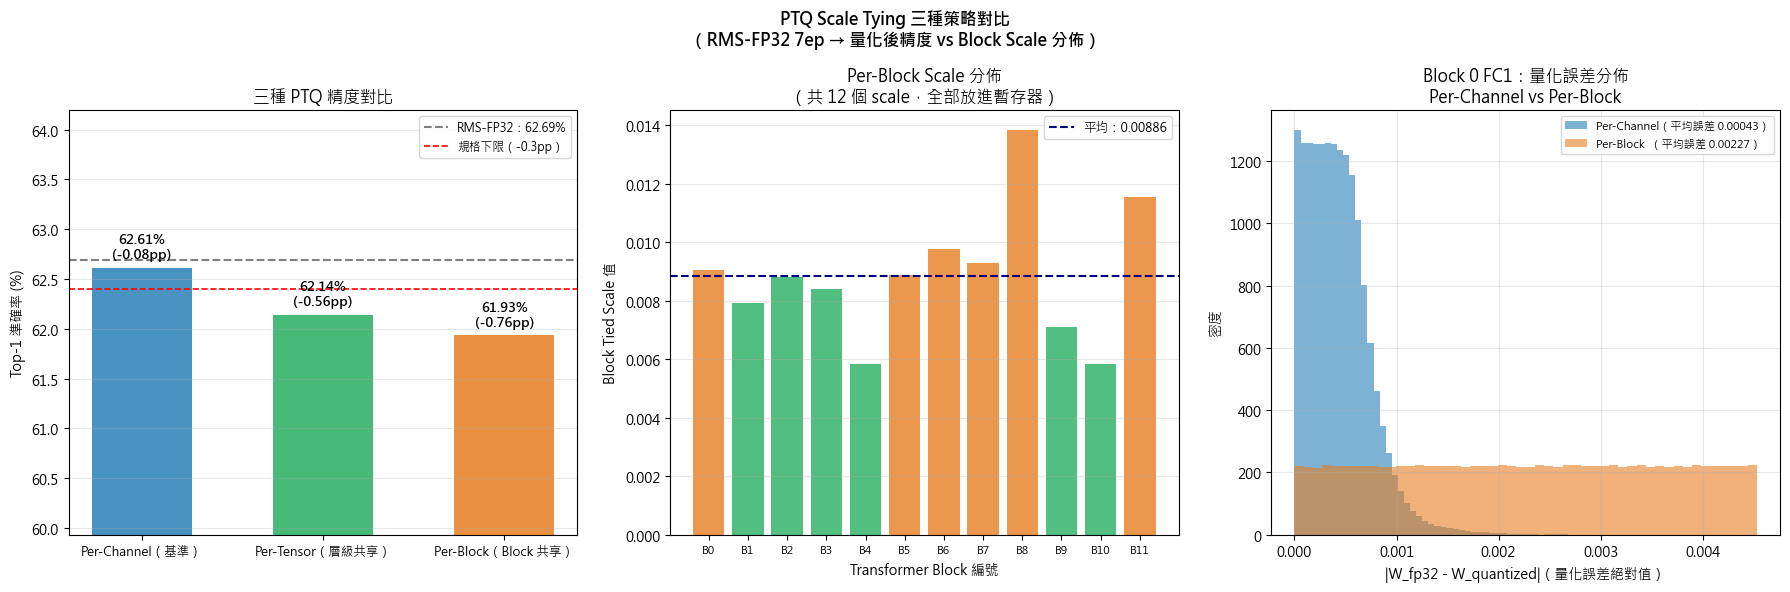

In [21]:
# ═══════════════════════════════════════════════════════════════
# Step 7B：Scale Tying 效果視覺化
# ═══════════════════════════════════════════════════════════════
#
# 左：三種 PTQ 精度對比條狀圖 + ΔAcc
# 中：Block 級 Scale 值（12 個 scale 的分佈）
# 右：Block 0 FC1 Weight 分佈對比（per-channel vs per-block 量化後）

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("PTQ Scale Tying 三種策略對比\n（RMS-FP32 7ep → 量化後精度 vs Block Scale 分佈）",
             fontsize=12, fontweight='bold')

# ── 左：精度條狀圖 ──
strategies  = ['Per-Channel（基準）', 'Per-Tensor（層級共享）', 'Per-Block（Block 共享）']
ptq_accs    = [acc_ptq_perchan, acc_ptq_pertens, acc_ptq_perblk]
ptq_deltas  = [a - acc_rms_fp32 for a in ptq_accs]
bar_colors  = ['#2980b9', '#27ae60', '#e67e22']

bars = axes[0].bar(range(3), ptq_accs, color=bar_colors, alpha=0.85, width=0.55)
for i, (bar, acc, d) in enumerate(zip(bars, ptq_accs, ptq_deltas)):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.1,
                 f"{acc:.2f}%\n({d:+.2f}pp)", ha='center', fontsize=9.5, fontweight='bold')
axes[0].axhline(acc_rms_fp32, color='gray', ls='--', lw=1.5,
                label=f'RMS-FP32：{acc_rms_fp32:.2f}%')
axes[0].axhline(acc_rms_fp32 + SPEC_INT8_THRESHOLD, color='red', ls='--', lw=1.2,
                label=f'規格下限（{SPEC_INT8_THRESHOLD}pp）')
axes[0].set_ylim(min(ptq_accs)-2, acc_rms_fp32+1.5)
axes[0].set_xticks([0,1,2]); axes[0].set_xticklabels(strategies, fontsize=9)
axes[0].set_ylabel('Top-1 準確率 (%)'); axes[0].set_title('三種 PTQ 精度對比')
axes[0].legend(fontsize=8.5); axes[0].grid(True, alpha=0.3, axis='y')

# ── 中：Block Scale 值分佈 ──
if blk_scales:
    axes[1].bar(range(len(blk_scales)), blk_scales,
                color=['#e67e22' if s > np.mean(blk_scales) else '#27ae60'
                       for s in blk_scales], alpha=0.8)
    axes[1].axhline(np.mean(blk_scales), color='navy', ls='--', lw=1.5,
                    label=f'平均：{np.mean(blk_scales):.5f}')
    axes[1].set_xticks(range(len(blk_scales)))
    axes[1].set_xticklabels([f'B{i}' for i in range(len(blk_scales))], fontsize=8)
    axes[1].set_xlabel('Transformer Block 編號')
    axes[1].set_ylabel('Block Tied Scale 值')
    axes[1].set_title(f'Per-Block Scale 分佈\n（共 {len(blk_scales)} 個 scale，全部放進暫存器）')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, '（從快取載入，無 blk_scales）', ha='center', va='center')
    axes[1].axis('off')

# ── 右：Block 0 FC1 Weight 量化誤差對比 ──
# Per-Channel 量化版
try:
    m_pchan = quantize_ptq_perchannel(model_rms).cpu()
    m_pblk, _ = quantize_ptq_perblock(model_rms)
    w_fp32 = model_rms.blocks[0].mlp.fc1.weight.detach().cpu().numpy().flatten()
    w_pchan = m_pchan.blocks[0].mlp.fc1.weight.detach().cpu().numpy().flatten()
    w_pblk  = m_pblk.blocks[0].mlp.fc1.weight.detach().cpu().numpy().flatten()

    err_pchan = np.abs(w_fp32 - w_pchan)
    err_pblk  = np.abs(w_fp32 - w_pblk)
    axes[2].hist(err_pchan, bins=50, color='#2980b9', alpha=0.6, density=True,
                 label=f'Per-Channel（平均誤差 {err_pchan.mean():.5f}）')
    axes[2].hist(err_pblk,  bins=50, color='#e67e22', alpha=0.6, density=True,
                 label=f'Per-Block  （平均誤差 {err_pblk.mean():.5f}）')
    axes[2].set_xlabel('|W_fp32 - W_quantized|（量化誤差絕對值）')
    axes[2].set_ylabel('密度')
    axes[2].set_title('Block 0 FC1：量化誤差分佈\nPer-Channel vs Per-Block')
    axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
    del m_pchan, m_pblk
except Exception as e:
    axes[2].text(0.5, 0.5, f'無法計算誤差：{e}', ha='center', va='center')
    axes[2].axis('off')

plt.tight_layout()
plt.savefig("ST_03_PTQ_ScaleTying對比.png", dpi=120)
plt.show()


---
## Step 8：QAT Scale Tying（STE + ScaleTieGroup 訓練）

**為何需要 QAT Scale Tying？**

PTQ Per-Block 直接量化，模型沒有機會適應「粗粒度 scale」引入的額外誤差。
QAT Per-Block：訓練時每次 forward 都用 Per-Block tied scale 做 Fake-Quant，
讓模型的 weight 主動調整以**適應 Block 級量化約束**，恢復部分精度。

### 對比實驗
| 方案 | QAT 策略 | Scale 粒度 |
|------|---------|-----------|
| QAT Per-Channel | QuantLinearSTE | per-row（向量） |
| **QAT Per-Block（Scale Tying）** | QuantLinearBlockTied + ScaleTieGroup | **per-block（純量）** |


In [22]:
# ═══════════════════════════════════════════════════════════════
# Step 8A：QAT Per-Channel STE（基準 QAT）
# ═══════════════════════════════════════════════════════════════

CKPT_QAT_PCHAN     = f"{CKPT_DIR}/rms_qat_perchan_best.pt"
CKPT_QAT_PCHAN_ACC = f"{CKPT_DIR}/acc_qat_perchan.txt"
hist_qat_pchan = []

if os.path.exists(CKPT_QAT_PCHAN_ACC):
    acc_qat_perchan = float(open(CKPT_QAT_PCHAN_ACC).read())
    print(f"[快取] QAT Per-Channel：{acc_qat_perchan:.2f}%")
else:
    print("═" * 60)
    print(f" QAT Per-Channel STE：{QAT_EPOCHS} epoch（LR={QAT_LR}）")
    print("═" * 60)
    model_qat_pc = inject_ste_perchannel(model_rms)
    model_qat_pc.to(DEVICE)
    criterion_q = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer_q = torch.optim.AdamW(
        get_llrd_groups(model_qat_pc, QAT_LR, decay=0.85), weight_decay=0.01)
    scheduler_q = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_q, T_max=QAT_EPOCHS * len(train_loader))
    best_pc = 0.0
    for ep in range(1, QAT_EPOCHS + 1):
        t0   = time.time()
        loss = train_one_epoch(model_qat_pc, train_loader, optimizer_q,
                               scheduler_q, criterion_q, DEVICE,
                               f"QAT-PC Ep{ep}/{QAT_EPOCHS}")
        acc  = evaluate(model_qat_pc, test_loader)
        hist_qat_pchan.append({'epoch': f'PC-{ep}', 'loss': loss, 'acc': acc})
        print(f"[QAT Per-Channel] Ep {ep}/{QAT_EPOCHS}  loss={loss:.4f}  acc={acc:.2f}%  ({time.time()-t0:.0f}s)")
        if acc > best_pc:
            best_pc = acc
            torch.save(model_qat_pc.state_dict(), CKPT_QAT_PCHAN)
    acc_qat_perchan = best_pc
    open(CKPT_QAT_PCHAN_ACC, 'w').write(str(acc_qat_perchan))
    print(f"\n[QAT Per-Channel 完成] 最佳：{acc_qat_perchan:.2f}%")

delta_qat_pc = acc_qat_perchan - acc_rms_fp32
print(f"ΔAcc vs RMS-FP32：{delta_qat_pc:+.2f}pp  "
      f"（規格 ≥ {SPEC_INT8_THRESHOLD}pp → {'✅' if delta_qat_pc >= SPEC_INT8_THRESHOLD else '❌'}）")


════════════════════════════════════════════════════════════
 QAT Per-Channel STE：3 epoch（LR=2e-05）
════════════════════════════════════════════════════════════
[inject-STE per-channel] 替換 48 個 Linear（head 保留 FP32）


[QAT Per-Channel] Ep 1/3  loss=1.3092  acc=63.13%  (227s)


[QAT Per-Channel] Ep 2/3  loss=1.2683  acc=62.91%  (234s)


[QAT Per-Channel] Ep 3/3  loss=1.2467  acc=63.00%  (235s)

[QAT Per-Channel 完成] 最佳：63.13%
ΔAcc vs RMS-FP32：+0.43pp  （規格 ≥ -0.3pp → ✅）


In [23]:
# ═══════════════════════════════════════════════════════════════
# Step 8B：QAT Per-Block Scale Tying（ScaleTieGroup + STE）
# ═══════════════════════════════════════════════════════════════
#
# 流程：
#   inject_block_tied_ste() → 替換 Linear → QuantLinearBlockTied
#   每個 Block 前向前：forward_pre_hook 重算 group.scale（tied pure scalar）
#   訓練：STE 梯度穿透 round，weight 主動適應粗粒度 scale
#   評估：等效 INT8 精度（per-block scale）
#
# 崩潰風險分析：
#   scale 粒度較粗 → 量化誤差比 per-channel 大
#   但 QAT 提供 gradient 路徑讓 weight 補償誤差
#   3 epoch 後應能恢復至接近 per-channel QAT 的精度

CKPT_QAT_PBLK     = f"{CKPT_DIR}/rms_qat_perblk_best.pt"
CKPT_QAT_PBLK_ACC = f"{CKPT_DIR}/acc_qat_perblk.txt"
hist_qat_pblk = []

if os.path.exists(CKPT_QAT_PBLK_ACC):
    acc_qat_perblk = float(open(CKPT_QAT_PBLK_ACC).read())
    print(f"[快取] QAT Per-Block Scale Tying：{acc_qat_perblk:.2f}%")
else:
    print("═" * 60)
    print(f" QAT Per-Block Scale Tying：{QAT_EPOCHS} epoch（LR={QAT_LR}）")
    print("═" * 60)

    # inject：所有 Block 內 Linear → QuantLinearBlockTied（+ pre_hook）
    model_qat_blk = inject_block_tied_ste(model_rms)
    model_qat_blk.to(DEVICE)

    # 確認 inject 正確：
    tied_count = sum(1 for m in model_qat_blk.modules()
                     if isinstance(m, QuantLinearBlockTied))
    print(f"  inject 確認：{tied_count} 個 QuantLinearBlockTied")

    criterion_b = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer_b = torch.optim.AdamW(
        get_llrd_groups(model_qat_blk, QAT_LR, decay=0.85), weight_decay=0.01)
    scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_b, T_max=QAT_EPOCHS * len(train_loader))

    print(f"\n  每個 Block 的 tied scale 動態更新（每次 forward 前由 pre_hook 重算）")
    print(f"  這確保 weight 更新後，scale 始終反映當前 weight 分佈")

    best_blk = 0.0
    for ep in range(1, QAT_EPOCHS + 1):
        t0 = time.time()
        # ── 訓練一個 Epoch ──
        model_qat_blk.train()
        ep_loss = ep_n = 0
        for x, y in tqdm(train_loader, desc=f"[QAT-Blk Ep{ep}/{QAT_EPOCHS}]",
                         leave=False, ncols=80):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer_b.zero_grad()
            logits = model_qat_blk(x)   # pre_hook 在此自動更新 12 個 tied scale
            loss   = criterion_b(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model_qat_blk.parameters(), 1.0)
            optimizer_b.step()
            scheduler_b.step()
            ep_loss += loss.item() * y.size(0); ep_n += y.size(0)
        avg_loss = ep_loss / ep_n

        acc = evaluate(model_qat_blk, test_loader)
        hist_qat_pblk.append({'epoch': f'Blk-{ep}', 'loss': avg_loss, 'acc': acc})
        print(f"[QAT Per-Block] Ep {ep}/{QAT_EPOCHS}  loss={avg_loss:.4f}  "
              f"acc={acc:.2f}%  ({time.time()-t0:.0f}s)")
        if acc > best_blk:
            best_blk = acc
            torch.save(model_qat_blk.state_dict(), CKPT_QAT_PBLK)
            print(f"  → 儲存最佳：{best_blk:.2f}%")

    acc_qat_perblk = best_blk
    open(CKPT_QAT_PBLK_ACC, 'w').write(str(acc_qat_perblk))
    print(f"\n[QAT Per-Block 完成] 最佳：{acc_qat_perblk:.2f}%")

delta_qat_blk = acc_qat_perblk - acc_rms_fp32
print(f"ΔAcc vs RMS-FP32：{delta_qat_blk:+.2f}pp  "
      f"（規格 ≥ {SPEC_INT8_THRESHOLD}pp → {'✅' if delta_qat_blk >= SPEC_INT8_THRESHOLD else '❌'}）")
print(f"vs QAT Per-Channel：{acc_qat_perblk - acc_qat_perchan:+.2f}pp（Scale Tying 代價）")


════════════════════════════════════════════════════════════
 QAT Per-Block Scale Tying：3 epoch（LR=2e-05）
════════════════════════════════════════════════════════════
[inject-block-tied] 48 Linear 替換完成
  12 個 Block 各 1 個 ScaleTieGroup（共 12 個 tied scale）
  head 保留 FP32 精度（分類頭不量化）
  inject 確認：48 個 QuantLinearBlockTied

  每個 Block 的 tied scale 動態更新（每次 forward 前由 pre_hook 重算）
  這確保 weight 更新後，scale 始終反映當前 weight 分佈


[QAT Per-Block] Ep 1/3  loss=1.3229  acc=63.08%  (238s)
  → 儲存最佳：63.08%


[QAT Per-Block] Ep 2/3  loss=1.2785  acc=63.03%  (240s)


[QAT Per-Block] Ep 3/3  loss=1.2544  acc=63.10%  (240s)
  → 儲存最佳：63.10%

[QAT Per-Block 完成] 最佳：63.10%
ΔAcc vs RMS-FP32：+0.40pp  （規格 ≥ -0.3pp → ✅）
vs QAT Per-Channel：-0.03pp（Scale Tying 代價）


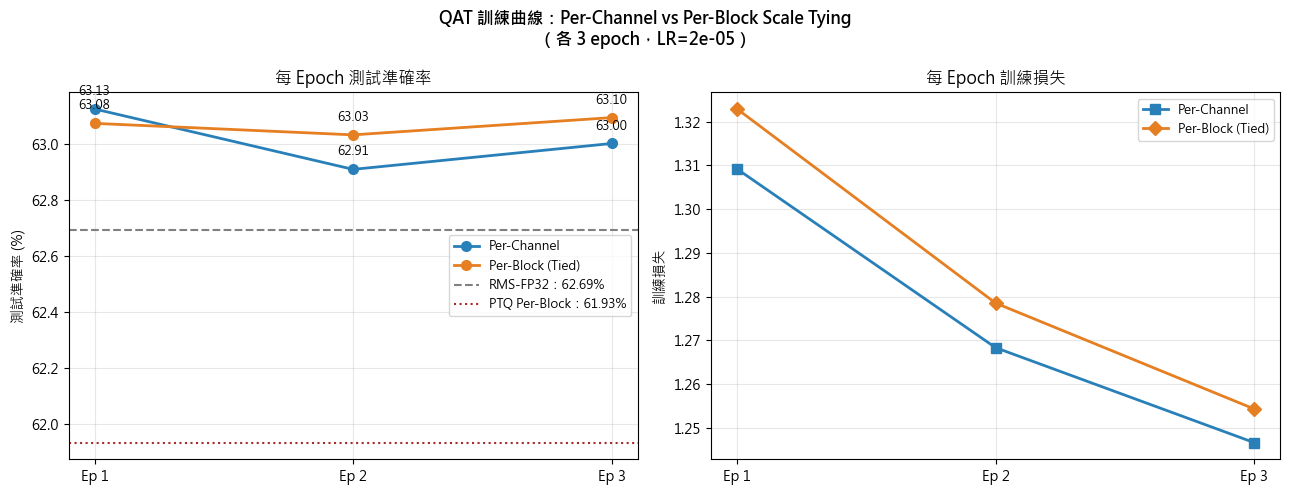

In [24]:
# ═══════════════════════════════════════════════════════════════
# Step 8C：QAT Per-Channel vs Per-Block 訓練曲線對比
# ═══════════════════════════════════════════════════════════════

if hist_qat_pchan or hist_qat_pblk:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"QAT 訓練曲線：Per-Channel vs Per-Block Scale Tying\n"
                 f"（各 {QAT_EPOCHS} epoch，LR={QAT_LR}）",
                 fontsize=12, fontweight='bold')

    def plot_qat_curve(ax, hist, color, label):
        if not hist: return
        x = range(len(hist))
        ax.plot(x, [h['acc']  for h in hist], 'o-', color=color, lw=2, ms=7, label=label)
        for xi, h in enumerate(hist):
            ax.text(xi, h['acc'] + 0.05, f"{h['acc']:.2f}", ha='center', fontsize=9)

    # 準確率
    if hist_qat_pchan: plot_qat_curve(axes[0], hist_qat_pchan, '#2980b9', 'Per-Channel')
    if hist_qat_pblk:  plot_qat_curve(axes[0], hist_qat_pblk,  '#e67e22', 'Per-Block (Tied)')
    axes[0].axhline(acc_rms_fp32,   color='gray',  ls='--', label=f'RMS-FP32：{acc_rms_fp32:.2f}%')
    axes[0].axhline(acc_ptq_perblk, color='brown', ls=':',  label=f'PTQ Per-Block：{acc_ptq_perblk:.2f}%')
    axes[0].set_ylabel('測試準確率 (%)'); axes[0].set_title('每 Epoch 測試準確率')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(range(QAT_EPOCHS))
    axes[0].set_xticklabels([f'Ep {i+1}' for i in range(QAT_EPOCHS)])

    # 損失
    if hist_qat_pchan:
        axes[1].plot(range(len(hist_qat_pchan)),
                     [h['loss'] for h in hist_qat_pchan],
                     's-', color='#2980b9', lw=2, ms=7, label='Per-Channel')
    if hist_qat_pblk:
        axes[1].plot(range(len(hist_qat_pblk)),
                     [h['loss'] for h in hist_qat_pblk],
                     'D-', color='#e67e22', lw=2, ms=7, label='Per-Block (Tied)')
    axes[1].set_ylabel('訓練損失'); axes[1].set_title('每 Epoch 訓練損失')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(range(QAT_EPOCHS))
    axes[1].set_xticklabels([f'Ep {i+1}' for i in range(QAT_EPOCHS)])

    plt.tight_layout()
    plt.savefig("ST_04_QAT_ScaleTying訓練曲線.png", dpi=120)
    plt.show()
else:
    print(f"（從快取載入）QAT Per-Channel：{acc_qat_perchan:.2f}%  QAT Per-Block：{acc_qat_perblk:.2f}%")


---
## Step 9：完整實驗結果比較（5 個方案 + Scale Tying 分析）

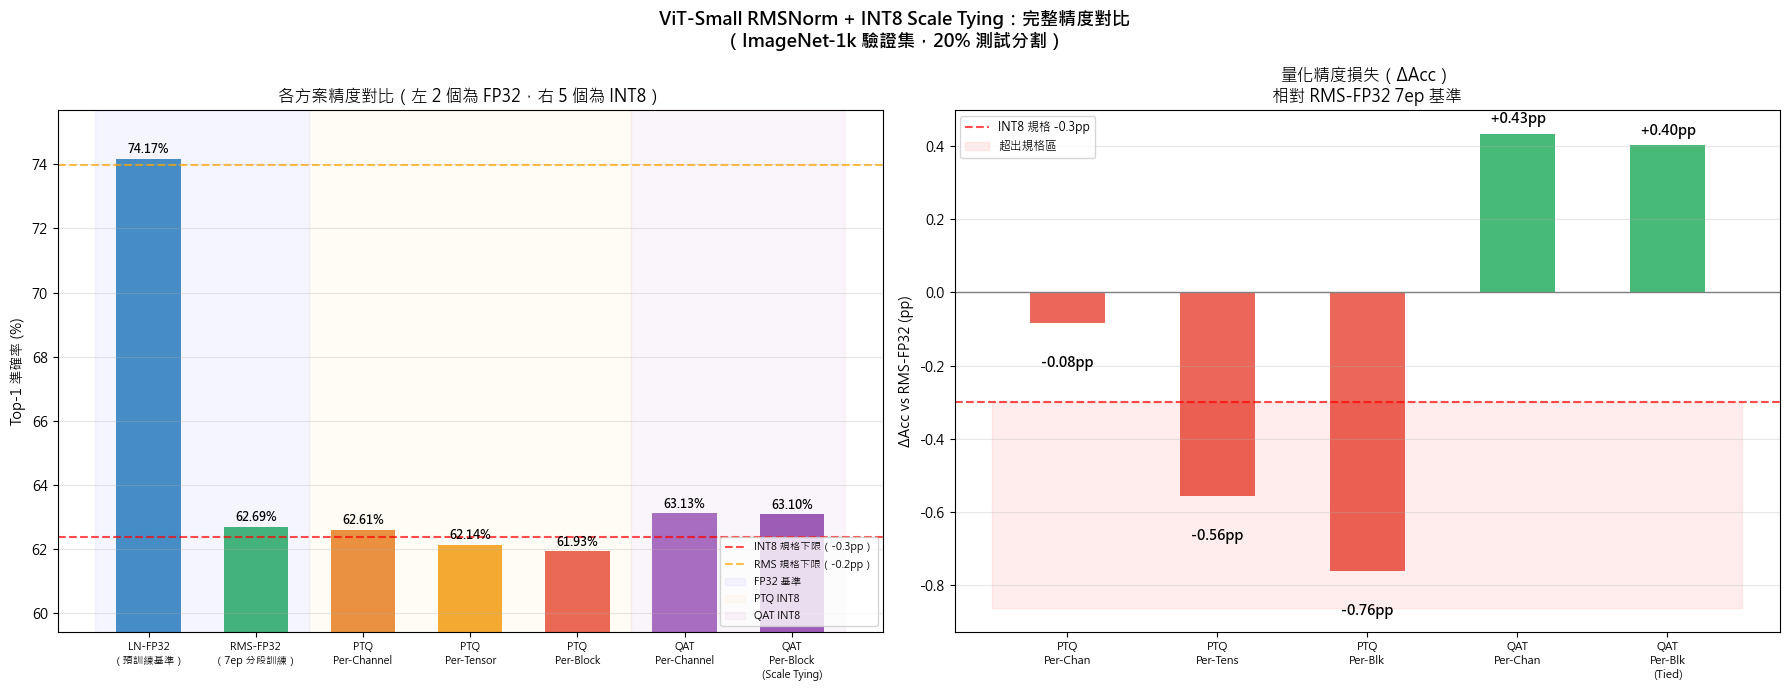

In [25]:
# ═══════════════════════════════════════════════════════════════
# Step 9A：完整精度對比圖（5 個方案）
# ═══════════════════════════════════════════════════════════════

all_results = {
    'LN-FP32\n（預訓練基準）'          : acc_ln_base,
    'RMS-FP32\n（7ep 分段訓練）'       : acc_rms_fp32,
    'PTQ\nPer-Channel'                 : acc_ptq_perchan,
    'PTQ\nPer-Tensor'                  : acc_ptq_pertens,
    'PTQ\nPer-Block'                   : acc_ptq_perblk,
    'QAT\nPer-Channel'                 : acc_qat_perchan,
    'QAT\nPer-Block\n(Scale Tying)'   : acc_qat_perblk,
}
labels = list(all_results.keys())
accs   = list(all_results.values())
colors = ['#2980b9', '#27ae60',
          '#e67e22', '#f39c12', '#e74c3c',
          '#9b59b6', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("ViT-Small RMSNorm + INT8 Scale Tying：完整精度對比\n"
             "（ImageNet-1k 驗證集，20% 測試分割）",
             fontsize=13, fontweight='bold')

# ── 左：條狀精度圖 ──
bars = axes[0].bar(range(len(accs)), accs, color=colors, alpha=0.85, width=0.6)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.08,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
y_min = min(accs) - 2.5
axes[0].set_ylim(y_min, max(accs) + 1.5)
axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, fontsize=7.5)
axes[0].set_ylabel('Top-1 準確率 (%)')
axes[0].set_title('各方案精度對比（左 2 個為 FP32，右 5 個為 INT8）')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(acc_rms_fp32 + SPEC_INT8_THRESHOLD, color='red', ls='--', alpha=0.7,
                label=f'INT8 規格下限（{SPEC_INT8_THRESHOLD}pp）')
axes[0].axhline(acc_ln_base + SPEC_RMS_THRESHOLD, color='orange', ls='--', alpha=0.7,
                label=f'RMS 規格下限（{SPEC_RMS_THRESHOLD}pp）')
# 區塊分組標記
axes[0].axvspan(-0.5, 1.5, alpha=0.04, color='blue',   label='FP32 基準')
axes[0].axvspan(1.5,  4.5, alpha=0.04, color='orange', label='PTQ INT8')
axes[0].axvspan(4.5,  6.5, alpha=0.04, color='purple', label='QAT INT8')
axes[0].legend(fontsize=7.5, loc='lower right')

# ── 右：ΔAcc 瀑布圖（相對 RMS-FP32）──
delta_labels = ['PTQ\nPer-Chan', 'PTQ\nPer-Tens', 'PTQ\nPer-Blk',
                'QAT\nPer-Chan', 'QAT\nPer-Blk\n(Tied)']
delta_vals   = [
    acc_ptq_perchan - acc_rms_fp32,
    acc_ptq_pertens - acc_rms_fp32,
    acc_ptq_perblk  - acc_rms_fp32,
    acc_qat_perchan - acc_rms_fp32,
    acc_qat_perblk  - acc_rms_fp32,
]
d_colors = ['#e74c3c' if v < 0 else '#27ae60' for v in delta_vals]
bars2 = axes[1].bar(range(len(delta_vals)), delta_vals, color=d_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars2, delta_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + (0.03 if v >= 0 else -0.12),
                 f'{v:+.2f}pp', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(0, color='gray', lw=1)
axes[1].axhline(SPEC_INT8_THRESHOLD, color='red', ls='--', alpha=0.7,
                label=f'INT8 規格 {SPEC_INT8_THRESHOLD}pp')
axes[1].fill_between([-0.5, 4.5], SPEC_INT8_THRESHOLD, min(delta_vals)-0.1,
                     alpha=0.07, color='red', label='超出規格區')
axes[1].set_xticks(range(len(delta_labels))); axes[1].set_xticklabels(delta_labels, fontsize=8)
axes[1].set_ylabel('ΔAcc vs RMS-FP32 (pp)')
axes[1].set_title('量化精度損失（ΔAcc）\n相對 RMS-FP32 7ep 基準')
axes[1].legend(fontsize=8.5); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("ST_05_完整精度對比.png", dpi=120)
plt.show()


In [26]:
# ═══════════════════════════════════════════════════════════════
# Step 9B：完整結果數值表（含 Scale Tying 分析）
# ═══════════════════════════════════════════════════════════════

# 記錄所有結果供最終判定
delta_perchan = acc_ptq_perchan - acc_rms_fp32
delta_pertens = acc_ptq_pertens - acc_rms_fp32
delta_perblk  = acc_ptq_perblk  - acc_rms_fp32
delta_qpc     = acc_qat_perchan - acc_rms_fp32
delta_qblk    = acc_qat_perblk  - acc_rms_fp32

print("═" * 85)
print(" ViT-Small RMSNorm + INT8 + Scale Tying 完整實驗報告".center(85))
print(" 規格書 v3.1 Phase 0（§6.6）+ Phase 1（INT8）驗證".center(85))
print("═" * 85)

print(f"\n{'方案':<28} {'Top-1 (%)':>10} {'ΔAcc (pp)':>12} {'Scale 數':>10} {'規格':>8}")
print("─" * 85)

rows_data = [
    ("LN-FP32（預訓練基準）",  acc_ln_base,     acc_ln_base - acc_ln_base,   "~28,000", "—"),
    ("RMS-FP32（7ep 分段）",  acc_rms_fp32,     acc_rms_fp32 - acc_ln_base,  "~28,000", "—"),
    ("PTQ Per-Channel",       acc_ptq_perchan,  delta_perchan,               "~28,000", "✅" if delta_perchan >= SPEC_INT8_THRESHOLD else "❌"),
    ("PTQ Per-Tensor（層級）", acc_ptq_pertens,  delta_pertens,               "~98",     "✅" if delta_pertens >= SPEC_INT8_THRESHOLD else "❌"),
    ("PTQ Per-Block（Block）", acc_ptq_perblk,   delta_perblk,                "12",      "✅" if delta_perblk  >= SPEC_INT8_THRESHOLD else "❌"),
    ("QAT Per-Channel STE",   acc_qat_perchan,  delta_qpc,                   "~28,000", "✅" if delta_qpc     >= SPEC_INT8_THRESHOLD else "❌"),
    ("QAT Per-Block（Tied）",  acc_qat_perblk,   delta_qblk,                  "12",      "✅" if delta_qblk    >= SPEC_INT8_THRESHOLD else "❌"),
]
for name, acc, d, n_sc, spec in rows_data:
    d_str = "—" if d == 0 else f"{d:+.2f}"
    print(f"  {name:<26} {acc:>10.2f} {d_str:>12} {n_sc:>10} {spec:>8}")

print("─" * 85)
print()
print("Scale Tying 精度代價分析：")
print(f"  PTQ：Per-Chan → Per-Tensor 代價：{delta_pertens - delta_perchan:+.2f}pp")
print(f"  PTQ：Per-Chan → Per-Block  代價：{delta_perblk  - delta_perchan:+.2f}pp")
print(f"  QAT 恢復（Per-Block vs PTQ Per-Block）：{delta_qblk - delta_perblk:+.2f}pp")
print(f"  QAT Scale Tying 代價（vs QAT Per-Chan）：{delta_qblk - delta_qpc:+.2f}pp")
print()

# PYNQ-Z2 BRAM 節省
print("FPGA（PYNQ-Z2）部署收益：")
perchan_scales = count_scales(model_rms)
perblk_scales  = len(model_rms.blocks)
print(f"  Per-Channel 需儲存 scale：{perchan_scales:,} 個 FP32 → {perchan_scales*4/1024:.1f} KB BRAM")
print(f"  Per-Block  需儲存 scale：{perblk_scales:,} 個 FP32 → {perblk_scales*4} Bytes（放暫存器，BRAM=0）")
print(f"  節省 BRAM：{perchan_scales / perblk_scales:.0f}x")
print()

print("規格書合規性驗證：")
checks = [
    ("§6.6 RMSNorm 精度損失 < 0.2pp", acc_rms_fp32 - acc_ln_base, SPEC_RMS_THRESHOLD),
    ("INT8 PTQ Per-Block 精度損失",    delta_perblk,               SPEC_INT8_THRESHOLD),
    ("INT8 QAT Per-Block 精度損失",    delta_qblk,                 SPEC_INT8_THRESHOLD),
    ("INT8 QAT Per-Channel 精度損失",  delta_qpc,                  SPEC_INT8_THRESHOLD),
]
for name, delta, threshold in checks:
    ok = delta >= threshold
    print(f"  [{'✅ 通過' if ok else '❌ 未通過'}] {name:<40}  "
          f"ΔAcc={delta:+.2f}pp（下限 {threshold}pp）")
print()
print("崩潰判定：QAT Per-Block Scale Tying",
      "✅ 未崩潰，模型穩定收斂" if abs(delta_qblk) < 2.0 else "⚠  精度損失過大，需調整策略")
print("═" * 85)

print("\n已儲存圖表：")
for fn in ["ST_01_資料集樣本.png", "ST_02_RMSNorm訓練曲線.png",
           "ST_03_PTQ_ScaleTying對比.png", "ST_04_QAT_ScaleTying訓練曲線.png",
           "ST_05_完整精度對比.png"]:
    print(f"  {fn}")


═════════════════════════════════════════════════════════════════════════════════════
                     ViT-Small RMSNorm + INT8 + Scale Tying 完整實驗報告                   
                        規格書 v3.1 Phase 0（§6.6）+ Phase 1（INT8）驗證                      
═════════════════════════════════════════════════════════════════════════════════════

方案                            Top-1 (%)    ΔAcc (pp)    Scale 數       規格
─────────────────────────────────────────────────────────────────────────────────────
  LN-FP32（預訓練基準）                  74.17            —    ~28,000        —
  RMS-FP32（7ep 分段）                62.69       -11.48    ~28,000        —
  PTQ Per-Channel                 62.61        -0.08    ~28,000        ✅
  PTQ Per-Tensor（層級）              62.14        -0.56        ~98        ❌
  PTQ Per-Block（Block）            61.93        -0.76         12        ❌
  QAT Per-Channel STE             63.13        +0.43    ~28,000        ✅
  QAT Per-Block（Tied）             63.10        +0.40      